In [1]:
import numpy as np
from scipy.io import loadmat
import h5py
from pathlib import Path
from matplotlib import pyplot as plt
from simulator.model import ModelConfig, Model
from simulator.sensor import Sensor
from analysis import get_reference_signal, find_peaks

import pickle

Pulse Period: 0.5000 s, Std: 0.000147285871982915 s
Pulse Period: 0.5000 s, Std: 0.0001261936282385524 s
Pulse Period: 0.5000 s, Std: 0.00013448916253011708 s
Pulse Period: 0.5000 s, Std: 0.0001935995371060739 s


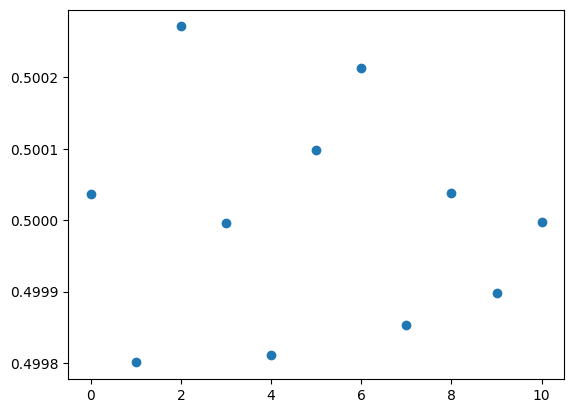

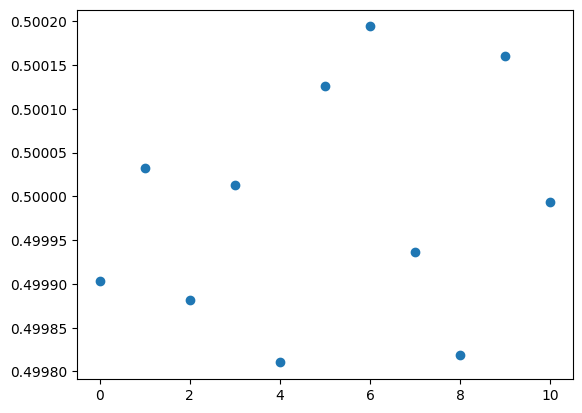

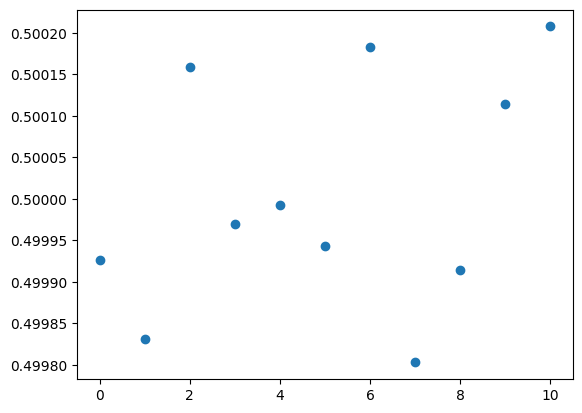

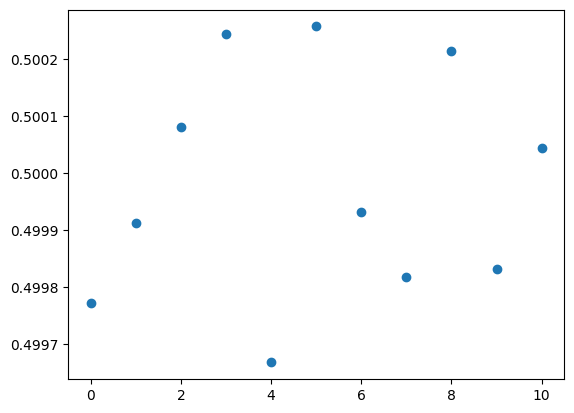

In [ ]:
# Sensor Calibration
# set a static target location (time, y, x)
y = 0
x = 0
time = np.arange(0, 1000, 0.1)
pos_cal = np.zeros((len(time), 3))
pos_cal[:, 0] = time
pos_cal[:, 1] = y
pos_cal[:, 2] = x

microphone_array = [Sensor(7, 4, 0),
                    Sensor(4, -3, 0),
                    Sensor(-4, 5, 0),
                    Sensor(-4, -6, 0)]

config_cal = ModelConfig(positions=pos_cal, sampling_rate=1000)

model_cal = Model(config_cal, microphone_array)

while model_cal.tick():
    model_cal.sample()

pickle.dump(model_cal, open("model_calibration.pkl", "wb"))

# distance(m) = c(m/s) * time(s) + e <- assumption: 'e' is contributed by time measurement, not propagation
# method, given a static target and static sensor, 'e' will be measured from the variance of the time of arrival
reference_signal, time = get_reference_signal()
toa_mic_1, _, _ = find_peaks(model_cal.sensor_array[0].data, model_cal.sensor_array[0].timestamp, threshold=50)
toa_mic_2, _, _ = find_peaks(model_cal.sensor_array[1].data, model_cal.sensor_array[1].timestamp, threshold=50)
toa_mic_3, _, _ = find_peaks(model_cal.sensor_array[2].data, model_cal.sensor_array[2].timestamp, threshold=50)
toa_mic_4, _, _ = find_peaks(model_cal.sensor_array[3].data, model_cal.sensor_array[3].timestamp, threshold=50)


pulse_period_1 = np.diff(toa_mic_1)
pp_mean = np.mean(pulse_period_1)
pp_std = np.std(pulse_period_1)
print(f"Pulse Period: {pp_mean:.4f} s, Std: {pp_std} s")

pulse_period_2 = np.diff(toa_mic_2)
pp_mean = np.mean(pulse_period_2)
pp_std = np.std(pulse_period_2)
print(f"Pulse Period: {pp_mean:.4f} s, Std: {pp_std} s")

pulse_period_3 = np.diff(toa_mic_3)
pp_mean = np.mean(pulse_period_3)
pp_std = np.std(pulse_period_3)
print(f"Pulse Period: {pp_mean:.4f} s, Std: {pp_std} s")

pulse_period_4 = np.diff(toa_mic_4)
pp_mean = np.mean(pulse_period_4)
pp_std = np.std(pulse_period_4)
print(f"Pulse Period: {pp_mean:.4f} s, Std: {pp_std} s")

plt.figure()
plt.plot(pulse_period_1, 'o')

plt.figure()
plt.plot(pulse_period_2, 'o')

plt.figure()
plt.plot(pulse_period_3, 'o')

plt.figure()
plt.plot(pulse_period_4, 'o')

In [4]:
toa_mic_1

[np.float64(0.5722890441197398),
 np.float64(1.0730683857919665),
 np.float64(1.563801310663633),
 np.float64(2.07724509637026),
 np.float64(2.5780630586564524),
 np.float64(3.0687015129337945),
 np.float64(3.573966580387515),
 np.float64(4.082656101740579),
 np.float64(4.57804967646086),
 np.float64(5.079543408480879),
 np.float64(5.573822714855497),
 np.float64(6.0740151585091455)]

In [ ]:
# Data Collection - w/ Motion
pos = pickle.load(open('data/position.pkl', 'rb'))

config = ModelConfig(positions=pos, sampling_rate=1000)

microphone_array = [Sensor(7, 4, 0),
                    Sensor(4, -3, 0),
                    Sensor(-4, 5, 0),
                    Sensor(-4, -6, 0)]

model = Model(config, microphone_array)

for i in range(60000):
    model.tick()
    model.sample()

pickle.dump(model.sensor_array, open('./data/sensor_array.pkl', 'wb'))

In [ ]:
# model.sensor_array[0].display()
n = 9000
N = 10000
plt.plot(model.sensor_array[0].timestamp[n:N], (model.sensor_array[0].data[n:N]))
plt.plot(model.sensor_array[1].timestamp[n:N], (model.sensor_array[1].data[n:N]))
plt.plot(model.sensor_array[2].timestamp[n:N], (model.sensor_array[2].data[n:N]))
plt.plot(model.sensor_array[3].timestamp[n:N], (model.sensor_array[3].data[n:N]))
# plt.plot(model.sensor_array[2].data[n:N])

In [ ]:

sensor_array = pickle.load(open('./data/sensor_array.pkl', 'rb'))

reference_signal, time = get_reference_signal()

toa_mic_1 = find_pulse_times(sensor_array[0], reference_signal, threshold=50)
toa_mic_2 = find_pulse_times(sensor_array[1], reference_signal, threshold=50)
toa_mic_3 = find_pulse_times(sensor_array[2], reference_signal, threshold=50)
toa_mic_4 = find_pulse_times(sensor_array[3], reference_signal, threshold=50)

plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(sensor_array[0].timestamp, sensor_array[0].data)
plt.plot(toa_mic_1, [0] * len(toa_mic_1), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(412)
plt.plot(sensor_array[1].timestamp, sensor_array[1].data)
plt.plot(toa_mic_2, [0] * len(toa_mic_2), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(413)
plt.plot(sensor_array[2].timestamp, sensor_array[2].data)
plt.plot(toa_mic_3, [0] * len(toa_mic_3), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(414)
plt.plot(sensor_array[3].timestamp, sensor_array[3].data)
plt.plot(toa_mic_4, [0] * len(toa_mic_4), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

pickle.dump(toa_mic_1, open('./data/toa_mic_1.pkl', 'wb'))
pickle.dump(toa_mic_2, open('./data/toa_mic_2.pkl', 'wb'))
pickle.dump(toa_mic_3, open('./data/toa_mic_3.pkl', 'wb'))
pickle.dump(toa_mic_4, open('./data/toa_mic_4.pkl', 'wb'))


/home/elyons/Documents/dev/SensorFusion/Lab1/.venv/lib/python3.12/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)
/home/elyons/Documents/dev/SensorFusion/Lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/elyons/Documents/dev/SensorFusion/Lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Amplitude')

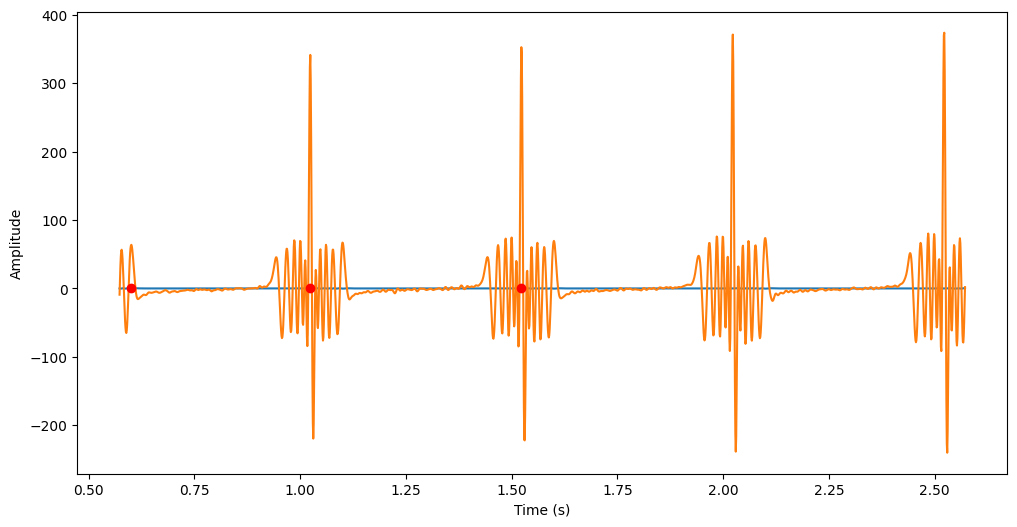

In [ ]:

sensor_array = pickle.load(open('./data/sensor_array.pkl', 'rb'))

reference_signal, time = get_reference_signal()

toa_mic_1, corr, time = find_pulse_times(sensor_array[0], reference_signal, threshold=50)

N_toa = 3
N_s = 5000

plt.figure(figsize=(12, 6))

plt.plot(sensor_array[0].timestamp[:N_s], sensor_array[0].data[:N_s])
plt.plot(time[:N_s], corr[:N_s])
plt.plot(toa_mic_1[:N_toa], [0] * N_toa, 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

